In [18]:
PALETTE = [
    "#5F4690",
    "#1D6996",
    "#38A6A5",
    "#0F8554",
    "#73AF48",
    "#EDAD08",
    "#E17C05",
    "#CC503E",
    "#94346E",
    "#6F4070",
    "#994E95",
    "#FF89F9",
    "#FBC5F9",
    "#666666",
]

RESULTS_PATH = "data/results.csv"
NUM_FOLDS = 5
MARKER_SIZE = 3

MODEL_NAMES = [
    "terramind_v1_tiny",
    "terramind_v1_small",
    "terramind_v1_base",
    "terramind_v1_large",
]
MODEL_LABELS = {
    "terramind_v1_tiny": "Tiny",
    "terramind_v1_small": "Small",
    "terramind_v1_base": "Base",
    "terramind_v1_large": "Large"
}
NUM_LAYERS_DICT = {
    "terramind_v1_tiny": 12,
    "terramind_v1_small": 12,
    "terramind_v1_base": 12,
    "terramind_v1_large": 24,
}

PROBE_NAMES = ["ridge", "xgboost", "mlp"]
PROBE_LABELS = {
    "ridge": "Ridge Regression",
    "xgboost": "XGBoost",
    "mlp": "MLP",
}
PROBE_COLORS = {
    "ridge": PALETTE[2],
    "xgboost": PALETTE[3],
    "mlp": PALETTE[7],
    "mlp_ridge_gain": PALETTE[6],
}

TARGET_NAMES = ["r2_lat", "r2_sin_lon", "r2_cos_lon"]
TARGET_LABELS = {
    "r2_lat": "Latitude",
    "r2_sin_lon": "Longitude (sin)",
    "r2_cos_lon": "Longitude (cos)",
}

DIM_REDUCTION_NAMES = ["none", "pca", "random"]
DIM_REDUCTION_LABELS = {
    "none": "No Dim. Red.",
    "pca": "PCA",
    "random": "Random",
}

CIRC_ENC_LABELS = {
    True: "Circular Encoding",
    False: "No Circular Encoding",
}
CIRC_ENC_COLORS = {
    True: PALETTE[1],
    False: PALETTE[12],
}

In [ ]:
import pandas as pd

TARGET_WEIGHTS = {
    "r2_lat": 1.0,
    "r2_sin_lon": 0.5,
    "r2_cos_lon": 0.5,
    "r2_lon": 1.0,
}

def load_df():
    df = pd.read_csv(RESULTS_PATH)
    for row in df.itertuples():
        weighted_r2 = 0.0
        weights = 0.0
        for target in TARGET_NAMES + ["r2_lon"]:
            r2 = getattr(row, target)
            if pd.notna(r2):
                weighted_r2 += r2 * TARGET_WEIGHTS[target]
                weights += TARGET_WEIGHTS[target]

        df.at[row.Index, "r2_all"] = weighted_r2 / weights

    return df

In [20]:
import numpy as np

def mean_bootstrap_ci(values, n_bootstrap=2000, confidence=0.95):
    values = np.asarray(values)

    if values.ndim != 1:
        raise ValueError("values must be a 1D array")
    if len(values) == 0:
        raise ValueError("values cannot be empty")

    mean = np.mean(values)
    n = len(values)

    # Bootstrap resamples
    samples = np.random.choice(values, size=(n_bootstrap, n), replace=True)
    bootstrap_means = samples.mean(axis=1)

    alpha = 1 - confidence
    ci_lower, ci_upper = np.percentile(
        bootstrap_means,
        [100 * alpha / 2, 100 * (1 - alpha / 2)]
    )

    return mean, ci_lower, ci_upper

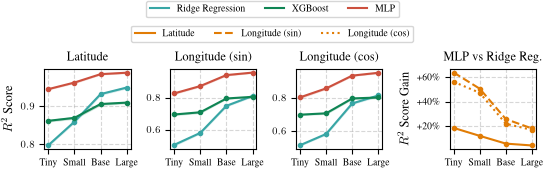


Saved to plots/probes_across_models.pdf


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles, figsizes
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

linestyle_handles = [
    Line2D([0], [0], color=PROBE_COLORS["mlp_ridge_gain"], lw=1.5, linestyle="-", label="Latitude"),
    Line2D([0], [0], color=PROBE_COLORS["mlp_ridge_gain"], lw=1.5, linestyle="--", label="Longitude (sin)"),
    Line2D([0], [0], color=PROBE_COLORS["mlp_ridge_gain"], lw=1.5, linestyle=":", label="Longitude (cos)")
]
color_handles = [
    Line2D([0], [0], color=PROBE_COLORS["ridge"], lw=1.5, label=PROBE_LABELS["ridge"]),
    Line2D([0], [0], color=PROBE_COLORS["xgboost"], lw=1.5, label=PROBE_LABELS["xgboost"]),
    Line2D([0], [0], color=PROBE_COLORS["mlp"], lw=1.5, label=PROBE_LABELS["mlp"])
]
target_linestyle_map = {
    "r2_lat": "-",
    "r2_sin_lon": "--",
    "r2_cos_lon": ":"
}

def percent_formatter(x, pos):
    return f"{x:+.0%}".replace("%", r"\%")

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

plt.rcParams.update(bundles.neurips2024())
plt.rcParams.update(figsizes.neurips2024(nrows=1, ncols=4, height_to_width_ratio=0.9, rel_width=1.0))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

df = load_df()

os.makedirs("plots", exist_ok=True)

mean_cache = {}

fig, axes = plt.subplots(1, 4, sharey=False)
for ax, tgt in zip(axes[:3], TARGET_NAMES, strict=True):
    for probe in PROBE_NAMES:
        means = []
        los = []
        his = []
        for model in MODEL_NAMES:
            sub_df = df[
                (df["model"] == model) &
                (df["probe"] == probe) &
                (df["layer"] == NUM_LAYERS_DICT[model] - 1) &
                (df["dim_reduction"] == "none") &
                (df["circular_encoding"] == True)
            ]

            assert len(sub_df) == NUM_FOLDS, f"Expected {NUM_FOLDS} folds, but got {len(sub_df)} for model={model}, probe={probe}, target={tgt}"

            scores = sub_df[tgt].values
            mean, lo, hi = mean_bootstrap_ci(scores)
            means.append(mean)
            los.append(lo)
            his.append(hi)

            mean_cache[(model, probe, tgt)] = mean

        x = np.arange(len(MODEL_NAMES))
        ax.plot(x, means, label=PROBE_LABELS[probe], color=PROBE_COLORS[probe], marker="o", markersize=MARKER_SIZE)
        ax.fill_between(x, los, his, alpha=0.2, color=PROBE_COLORS[probe])

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[model] for model in MODEL_NAMES])
    ax.set_title(TARGET_LABELS[tgt])
    ax.grid(True, linestyle="--", alpha=0.5)
        
axes[0].set_ylabel("$R^2$ Score")

for tgt in TARGET_NAMES:
    rel_gains = []
    for model in MODEL_NAMES:
        mlp_mean = mean_cache[(model, "mlp", tgt)]
        ridge_mean = mean_cache[(model, "ridge", tgt)]
        rel_gain = (mlp_mean - ridge_mean) / abs(ridge_mean)
        rel_gains.append(rel_gain)

    x = np.arange(len(MODEL_NAMES))
    axes[-1].plot(
        x, 
        rel_gains, 
        label=TARGET_LABELS[tgt], 
        color=PROBE_COLORS["mlp_ridge_gain"], 
        linestyle=target_linestyle_map[tgt],
        marker="o",
        markersize=MARKER_SIZE
    )
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([MODEL_LABELS[model] for model in MODEL_NAMES])
axes[-1].set_title("MLP vs Ridge Reg.")
axes[-1].set_ylabel("$R^2$ Score Gain")
axes[-1].grid(True, linestyle="--", alpha=0.5)
axes[-1].yaxis.set_major_formatter(FuncFormatter(percent_formatter))

fig.legend(
    color_handles,
    PROBE_LABELS.values(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.42),
    ncol=len(PROBE_NAMES),
    frameon=True,
)

fig.legend(
    linestyle_handles,
    TARGET_LABELS.values(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.22),
    ncol=len(TARGET_NAMES),
    frameon=True,
)

plt.savefig("plots/probes_across_models.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/probes_across_models.pdf")

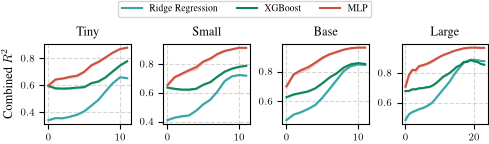


Saved to plots/probes_across_layers.pdf


In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles, figsizes

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

plt.rcParams.update(bundles.neurips2024())
plt.rcParams.update(figsizes.neurips2024(nrows=1, ncols=4, height_to_width_ratio=1.0, rel_width=0.9))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

df = load_df()

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 4, sharey=False, sharex=False)
for ax, model in zip(axes, MODEL_NAMES, strict=True):
    for probe in PROBE_NAMES:
        means = []
        los = []
        his = []
        for layer in range(NUM_LAYERS_DICT[model]):
            sub_df = df[
                (df["model"] == model) &
                (df["probe"] == probe) &
                (df["layer"] == layer) &
                (df["dim_reduction"] == "none") &
                (df["circular_encoding"] == True)
            ]

            assert len(sub_df) == NUM_FOLDS, f"Expected {NUM_FOLDS} folds, but got {len(sub_df)} for model={model}, probe={probe}"

            scores = sub_df["r2_all"].values
            mean, lo, hi = mean_bootstrap_ci(scores)
            means.append(mean)
            los.append(lo)
            his.append(hi)

        x = np.arange(NUM_LAYERS_DICT[model])
        ax.plot(x, means, label=PROBE_LABELS[probe], color=PROBE_COLORS[probe])
        ax.fill_between(x, los, his, alpha=0.2, color=PROBE_COLORS[probe])

    ax.set_title(MODEL_LABELS[model])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_ylabel("Combined $R^2$")

fig.legend(
    color_handles,
    PROBE_LABELS.values(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.22),
    ncol=len(PROBE_NAMES),
    frameon=True,
)

plt.savefig("plots/probes_across_layers.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/probes_across_layers.pdf")

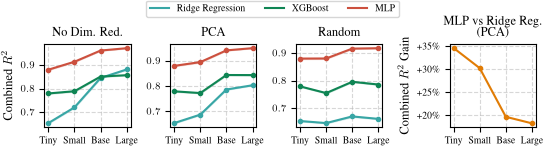


Saved to plots/probes_across_models_dim_red.pdf


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles, figsizes

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

plt.rcParams.update(bundles.neurips2024())
plt.rcParams.update(figsizes.neurips2024(nrows=1, ncols=4, height_to_width_ratio=1.0, rel_width=1.0))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

df = load_df()

os.makedirs("plots", exist_ok=True)

pca_mean_cache = {}

fig, axes = plt.subplots(1, 4, sharey=False, sharex=False)
for ax, dim_red in zip(axes[:3], DIM_REDUCTION_NAMES, strict=True):
    for probe in PROBE_NAMES:
        means = []
        los = []
        his = []
        for model in MODEL_NAMES:
            sub_df = df[
                (df["model"] == model) &
                (df["probe"] == probe) &
                (df["layer"] == NUM_LAYERS_DICT[model] - 1) &
                (df["dim_reduction"] == (dim_red if model != "terramind_v1_tiny" else "none")) &
                (df["circular_encoding"] == True)
            ]

            assert len(sub_df) == NUM_FOLDS, f"Expected {NUM_FOLDS} folds, but got {len(sub_df)} for model={model}, probe={probe}, dim_red={dim_red}"

            scores = sub_df["r2_all"].values
            mean, lo, hi = mean_bootstrap_ci(scores)
            means.append(mean)
            los.append(lo)
            his.append(hi)

            if dim_red == "pca":
                for tgt in TARGET_NAMES + ["r2_all"]:
                    scores = sub_df[tgt].values
                    mean, _, _ = mean_bootstrap_ci(scores)
                    pca_mean_cache[(model, probe, tgt)] = mean

        x = np.arange(len(MODEL_NAMES))
        ax.plot(x, means, label=PROBE_LABELS[probe], color=PROBE_COLORS[probe], marker="o", markersize=MARKER_SIZE)
        ax.fill_between(x, los, his, alpha=0.2, color=PROBE_COLORS[probe])

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[model] for model in MODEL_NAMES])
    ax.set_title(DIM_REDUCTION_LABELS[dim_red])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_ylabel("Combined $R^2$")

rel_gains = []
for model in MODEL_NAMES:
    mlp_mean = pca_mean_cache[(model, "mlp", "r2_all")]
    ridge_mean = pca_mean_cache[(model, "ridge", "r2_all")]
    rel_gain = (mlp_mean - ridge_mean) / abs(ridge_mean)
    rel_gains.append(rel_gain)

x = np.arange(len(MODEL_NAMES))
axes[-1].plot(
    x, 
    rel_gains,
    color=PROBE_COLORS["mlp_ridge_gain"], 
    marker="o",
    markersize=MARKER_SIZE
)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([MODEL_LABELS[model] for model in MODEL_NAMES])
axes[-1].set_title("MLP vs Ridge Reg.\n(PCA)")
axes[-1].set_ylabel("Combined $R^2$ Gain")
axes[-1].grid(True, linestyle="--", alpha=0.5)
axes[-1].yaxis.set_major_formatter(FuncFormatter(percent_formatter))

fig.legend(
    color_handles,
    PROBE_LABELS.values(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=len(PROBE_NAMES),
    frameon=True,
)

plt.savefig("plots/probes_across_models_dim_red.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/probes_across_models_dim_red.pdf")

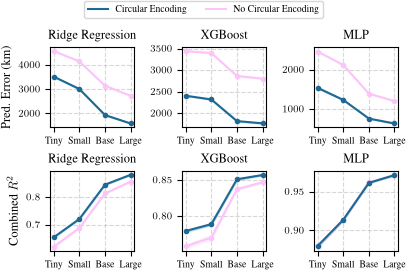


Saved to plots/circular_encoding.pdf


In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles, figsizes

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

plt.rcParams.update(bundles.neurips2024())
plt.rcParams.update(figsizes.neurips2024(nrows=2, ncols=3, height_to_width_ratio=0.9, rel_width=0.75))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

circ_enc_color_handles = [
    Line2D([0], [0], color=CIRC_ENC_COLORS[True], lw=1.5, label=CIRC_ENC_LABELS[True]),
    Line2D([0], [0], color=CIRC_ENC_COLORS[False], lw=1.5, label=CIRC_ENC_LABELS[False])
]

df = load_df()

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(2, 3, sharey=False, sharex=False)
for ax_, metric in zip(axes, ["pred_error_km", "r2_all"], strict=True):
    for ax, probe in zip(ax_, PROBE_NAMES, strict=True):
        for circ_enc in [False, True]:
            means = []
            los = []
            his = []
            for model in MODEL_NAMES:
                sub_df = df[
                    (df["model"] == model) &
                    (df["probe"] == probe) &
                    (df["layer"] == NUM_LAYERS_DICT[model] - 1) &
                    (df["dim_reduction"] == "none") &
                    (df["circular_encoding"] == circ_enc)
                ]

                assert len(sub_df) == NUM_FOLDS, f"Expected {NUM_FOLDS} folds, but got {len(sub_df)} for model={model}, probe={probe}"

                scores = sub_df[metric].values
                mean, lo, hi = mean_bootstrap_ci(scores)
                means.append(mean)
                los.append(lo)
                his.append(hi)

            x = np.arange(len(MODEL_NAMES))
            ax.plot(x, means, label=CIRC_ENC_LABELS[circ_enc], color=CIRC_ENC_COLORS[circ_enc], marker="o", markersize=MARKER_SIZE)
            ax.fill_between(x, los, his, alpha=0.2, color=CIRC_ENC_COLORS[circ_enc])

            ax.set_xticks(x)
            ax.set_xticklabels([MODEL_LABELS[model] for model in MODEL_NAMES])
            ax.set_title(f"{PROBE_LABELS[probe]}")
            ax.grid(True, linestyle="--", alpha=0.5)

axes[0, 0].set_ylabel("Pred. Error (km)")
axes[1, 0].set_ylabel("Combined $R^2$")

fig.legend(
    circ_enc_color_handles,
    CIRC_ENC_LABELS.values(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=len(PROBE_NAMES),
    frameon=True,
)

plt.savefig("plots/circular_encoding.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/circular_encoding.pdf")

tiny ridge pred error 3514.4177
large ridge pred error 1588.5701
large mlp pred error 632.7326


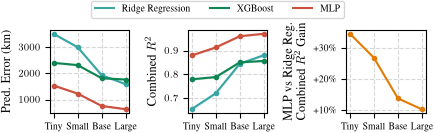


Saved to plots/front_page.pdf


In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tueplots import bundles, figsizes

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

plt.rcParams.update(bundles.neurips2024())
plt.rcParams.update(figsizes.neurips2024(nrows=1, ncols=3, height_to_width_ratio=0.75, rel_width=0.8))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

df = load_df()

os.makedirs("plots", exist_ok=True)

mean_cache_agg = {}

fig, axes = plt.subplots(1, 3, sharey=False)
for ax, metric in zip(axes[:2], ["pred_error_km", "r2_all"], strict=True):
    for probe in PROBE_NAMES:
        means = []
        los = []
        his = []
        for model in MODEL_NAMES:
            sub_df = df[
                (df["model"] == model) &
                (df["probe"] == probe) &
                (df["layer"] == NUM_LAYERS_DICT[model] - 1) &
                (df["dim_reduction"] == "none") &
                (df["circular_encoding"] == True)
            ]

            assert len(sub_df) == NUM_FOLDS, f"Expected {NUM_FOLDS} folds, but got {len(sub_df)} for model={model}, probe={probe}, target={tgt}"

            scores = sub_df[metric].values
            mean, lo, hi = mean_bootstrap_ci(scores)
            means.append(mean)
            los.append(lo)
            his.append(hi)

            mean_cache_agg[(model, probe, metric)] = mean

        x = np.arange(len(MODEL_NAMES))
        ax.plot(x, means, label=PROBE_LABELS[probe], color=PROBE_COLORS[probe], marker="o", markersize=MARKER_SIZE)
        ax.fill_between(x, los, his, alpha=0.2, color=PROBE_COLORS[probe])

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[model] for model in MODEL_NAMES])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_ylabel("Pred. Error (km)")
axes[1].set_ylabel("Combined $R^2$")

rel_gains = []
for model in MODEL_NAMES:
    mlp_mean = mean_cache_agg[(model, "mlp", "r2_all")]
    ridge_mean = mean_cache_agg[(model, "ridge", "r2_all")]
    rel_gain = (mlp_mean - ridge_mean) / abs(ridge_mean)
    rel_gains.append(rel_gain)

x = np.arange(len(MODEL_NAMES))
axes[-1].plot(
    x, 
    rel_gains, 
    color=PROBE_COLORS["mlp_ridge_gain"], 
    marker="o",
    markersize=MARKER_SIZE
)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels([MODEL_LABELS[model] for model in MODEL_NAMES])
axes[-1].set_ylabel("MLP vs Ridge Reg.\nCombined $R^2$ Gain")
axes[-1].grid(True, linestyle="--", alpha=0.5)
axes[-1].yaxis.set_major_formatter(FuncFormatter(percent_formatter))

fig.legend(
    color_handles,
    PROBE_LABELS.values(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.27),
    ncol=len(PROBE_NAMES),
    frameon=True,
)

print(f"tiny ridge pred error {mean_cache_agg[('terramind_v1_tiny', 'ridge', 'pred_error_km')]:.4f}")
print(f"large ridge pred error {mean_cache_agg[('terramind_v1_large', 'ridge', 'pred_error_km')]:.4f}")
print(f"large mlp pred error {mean_cache_agg[('terramind_v1_large', 'mlp', 'pred_error_km')]:.4f}")

plt.savefig("plots/front_page.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/front_page.pdf")